In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [21]:
import sys
from pathlib import Path

project_root = Path.cwd().parents[1]
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

In [22]:
from src.preprocessing import convert_dtypes

In [23]:
customer_features = pd.read_csv(r"C:\Users\Lenovo\Customer-Intelligence-Platform\data\processed\customer_summary_clean.csv")

In [24]:
customer_features.head(3)

,customer_unique_id,total_orders,total_spent,total_products,total_freight_paid,avg_order_value,avg_review_score,avg_delivery_days,first_purchase,last_purchase,customer_lifetime_days
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90,1.0,12.00,141.90,5.0,6.0,2018-05-10,2018-05-10,0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19,1.0,8.29,27.19,4.0,3.0,2018-05-07,2018-05-07,0
2,0000f46a3911fa3c0805444483337064,1,86.22,1.0,17.22,86.22,3.0,26.0,2017-03-10,2017-03-10,0


In [25]:
customer_features.info()

<class 'pandas.DataFrame'>
RangeIndex: 95419 entries, 0 to 95418
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_unique_id      95419 non-null  str    
 1   total_orders            95419 non-null  int64  
 2   total_spent             95419 non-null  float64
 3   total_products          95419 non-null  float64
 4   total_freight_paid      95419 non-null  float64
 5   avg_order_value         95419 non-null  float64
 6   avg_review_score        94720 non-null  float64
 7   avg_delivery_days       93355 non-null  float64
 8   first_purchase          95419 non-null  str    
 9   last_purchase           95419 non-null  str    
 10  customer_lifetime_days  95419 non-null  int64  
dtypes: float64(6), int64(2), str(3)
memory usage: 8.0 MB


In [26]:
customer_datetime_columns = [
    "first_purchase",
    "last_purchase"
]

In [28]:
customer_features = convert_dtypes(customer_features, datetime_columns = customer_datetime_columns)

In [29]:
customer_features.info()

<class 'pandas.DataFrame'>
RangeIndex: 95419 entries, 0 to 95418
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   customer_unique_id      95419 non-null  str           
 1   total_orders            95419 non-null  int64         
 2   total_spent             95419 non-null  float64       
 3   total_products          95419 non-null  float64       
 4   total_freight_paid      95419 non-null  float64       
 5   avg_order_value         95419 non-null  float64       
 6   avg_review_score        94720 non-null  float64       
 7   avg_delivery_days       93355 non-null  float64       
 8   first_purchase          95419 non-null  datetime64[us]
 9   last_purchase           95419 non-null  datetime64[us]
 10  customer_lifetime_days  95419 non-null  int64         
dtypes: datetime64[us](2), float64(6), int64(2), str(1)
memory usage: 8.0 MB


### Customer Feature 1: Recency

In [42]:
reference_date = customer_features["last_purchase"].max()

print(reference_date)

2018-09-03 00:00:00


In [43]:
customer_features["recency_days"] = (
    reference_date - customer_features["last_purchase"]
).dt.days

In [44]:
customer_features["recency_days"].describe()

count    95419.000000
mean       243.496484
std        153.153950
min          0.000000
25%        119.000000
50%        224.000000
75%        353.000000
max        729.000000
Name: recency_days, dtype: float64

In [45]:
customer_features[[
    "last_purchase",
    "recency_days"
]].head()

,last_purchase,recency_days
0,2018-05-10,116
1,2018-05-07,119
2,2017-03-10,542
3,2017-10-12,326
4,2017-11-14,293


In [46]:
customer_features["recency_days"].min()

np.int64(0)

In [47]:
customer_features["recency_days"].max()

np.int64(729)

#### Distribution

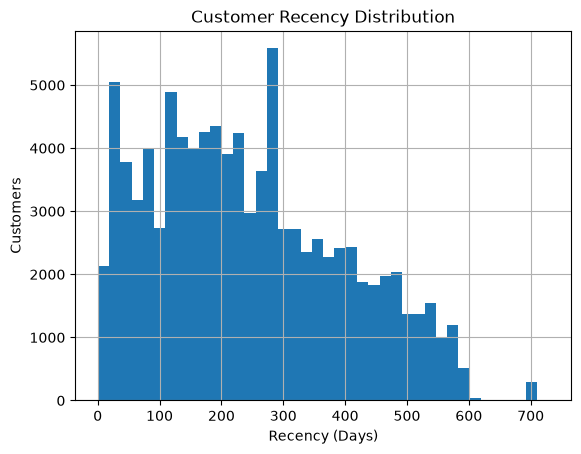

In [48]:
customer_features["recency_days"].hist(bins=40)
plt.xlabel("Recency (Days)")
plt.ylabel("Customers")
plt.title("Customer Recency Distribution")
plt.show()

In [49]:
customer_features.head(5)

,customer_unique_id,total_orders,total_spent,total_products,total_freight_paid,avg_order_value,avg_review_score,avg_delivery_days,first_purchase,last_purchase,customer_lifetime_days,recency_days
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90,1.0,12.00,141.90,5.0,6.0,2018-05-10,2018-05-10,0,116
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19,1.0,8.29,27.19,4.0,3.0,2018-05-07,2018-05-07,0,119
2,0000f46a3911fa3c0805444483337064,1,86.22,1.0,17.22,86.22,3.0,26.0,2017-03-10,2017-03-10,0,542
3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62,1.0,17.63,43.62,4.0,20.0,2017-10-12,2017-10-12,0,326
4,0004aac84e0df4da2b147fca70cf8255,1,196.89,1.0,16.89,196.89,5.0,13.0,2017-11-14,2017-11-14,0,293


### Customer Feature 2: Average Basket size

In [51]:
customer_features["avg_basket_size"] = (customer_features["total_products"] / customer_features["total_orders"])

In [52]:
customer_features["avg_basket_size"].describe()

count    95419.000000
mean         1.139081
std          0.526848
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         21.000000
Name: avg_basket_size, dtype: float64

#### check null value

In [53]:
customer_features["avg_basket_size"].isna().sum()

np.int64(0)

#### check infinite value

In [54]:
import numpy as np

np.isinf(customer_features["avg_basket_size"]).sum()

np.int64(0)

In [55]:
customer_features[
    [
        "total_products",
        "total_orders",
        "avg_basket_size"
    ]
].head(10)

,total_products,total_orders,avg_basket_size
0,1.0,1,1.0
1,1.0,1,1.0
2,1.0,1,1.0
3,1.0,1,1.0
4,1.0,1,1.0
5,1.0,1,1.0
6,1.0,1,1.0
7,2.0,1,2.0
8,1.0,1,1.0
9,1.0,1,1.0


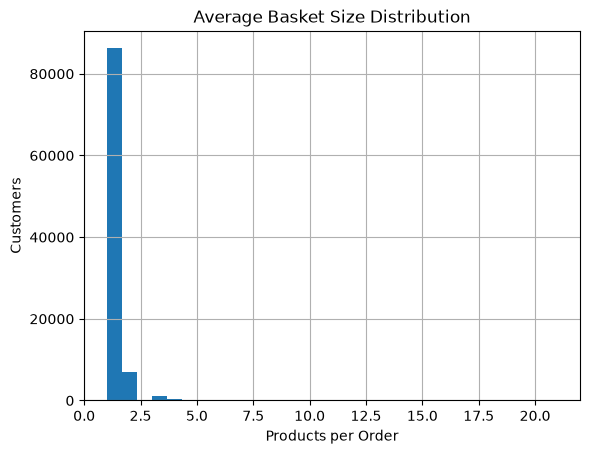

In [56]:
import matplotlib.pyplot as plt

customer_features["avg_basket_size"].hist(bins=30)

plt.title("Average Basket Size Distribution")
plt.xlabel("Products per Order")
plt.ylabel("Customers")
plt.show()

### Customer Feature 3: Frieght Ratio

In [57]:
customer_features["freight_ratio"] = (customer_features["total_freight_paid"] / customer_features["total_spent"])

In [58]:
customer_features["freight_ratio"].describe()

count    95419.000000
mean         0.207910
std          0.124982
min          0.000000
25%          0.116290
50%          0.182941
75%          0.274264
max          0.955451
Name: freight_ratio, dtype: float64

In [59]:
customer_features["freight_ratio"].isna().sum()

np.int64(0)

In [61]:

np.isinf(customer_features["freight_ratio"]).sum()

np.int64(0)

In [62]:
customer_features[
    [
        "total_spent",
        "total_freight_paid",
        "freight_ratio"
    ]
].head(10)

,total_spent,total_freight_paid,freight_ratio
0,141.90,12.00,0.084567
1,27.19,8.29,0.304892
2,86.22,17.22,0.199722
3,43.62,17.63,0.404172
4,196.89,16.89,0.085784
5,166.98,12.98,0.077734
6,35.38,7.39,0.208875
7,419.18,37.18,0.088697
8,150.12,15.12,0.100719
9,129.76,24.86,0.191584


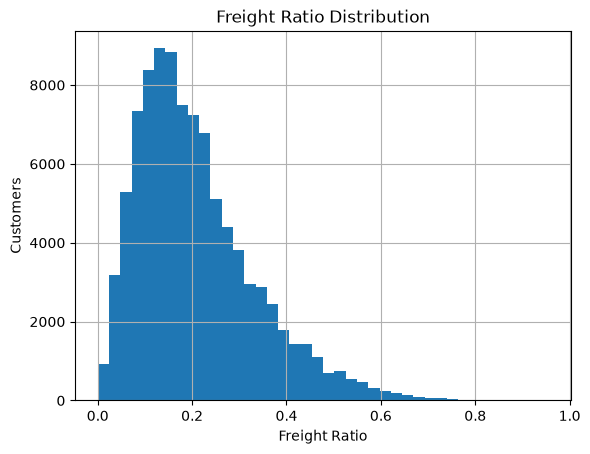

In [63]:
import matplotlib.pyplot as plt

customer_features["freight_ratio"].hist(bins=40)

plt.title("Freight Ratio Distribution")
plt.xlabel("Freight Ratio")
plt.ylabel("Customers")

plt.show()